# インド株 ファクター検証 — Step 10: CGO の符号分解（益側 / 損側）

処分効果は符号で非対称（含み**益** = 売り急ぎ → 過小反応、含み**損** = 塩漬け → 遅れた投げ）
のはずなので、CGO を符号で分けて特性を調べる。ベースは Step 9 の結論に従い **5年 CGO**。

## 4つのスコア定義

| スコア | 定義 | 注意点 |
|---|---|---|
| `gain_cens` | $\max(CGO, 0)$ → Blom | **損失側の全銘柄が 0 に縮退**（巨大タイ）。分位境界がタイの中を通る |
| `loss_cens` | $\min(CGO, 0)$ → Blom | 益側の全銘柄が 0 に縮退（Q5 側がタイ） |
| `gain_only` | $CGO$（$CGO>0$ のみ、他は NaN）→ Blom | タイなし。**含み益銘柄の中で**の順位。損側は NA バケットに出る |
| `loss_only` | $CGO$（$CGO<0$ のみ）→ Blom | タイなし。**含み損銘柄の中で**の順位 |

censored 版（ご提案）は「益の大きさ + 益があるか」の複合、
conditional 版は「符号の情報」と「符号内の濃淡」を分離する。
タイの割合は `frac_mode` で定量化して比較する。

規約は Step 9・11 と同じ（**日次ベース**、N=1260営業日、min=N、評価 200801〜、Blom、EW、Q5=最上位）。
スコアは事前計算済みの `data/cgo/` の `cgo_60m` を使用。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 250, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.3f}")

START, END = 200801, 202607
Q = 5
WEIGHTING = "ew"
FIGDIR = "10_cgo_sign"
MIN_UNIVERSE = 50    # conditional 版は片側の銘柄数が暴落期に激減するため必須

In [2]:
cgo = fl.cgo.load_cgo_monthly(["cgo_60m"], start=START, end=END)["cgo_60m"]
panel = fl.data.build_panel(["mom12_1"], start=START, end=END)
panel["cgo"] = cgo.reindex(panel.index)

panel["gain_cens"] = panel["cgo"].clip(lower=0.0)
panel["loss_cens"] = panel["cgo"].clip(upper=0.0)
panel["gain_only"] = panel["cgo"].where(panel["cgo"] > 0)
panel["loss_only"] = panel["cgo"].where(panel["cgo"] < 0)

SCORES = ["cgo", "gain_cens", "loss_cens", "gain_only", "loss_only"]
panel = fl.preprocess.standardize_panel(panel, SCORES + ["mom12_1"], method="blom")

## 1. 符号の構成比（マーケット状態の指標でもある）

含み益銘柄比率: 平均 0.63  最小 0.055 (200902)  最大 0.93 (202407)
gain側銘柄数 最小: 12 (200902)  loss側銘柄数 最小: 17 (201406)


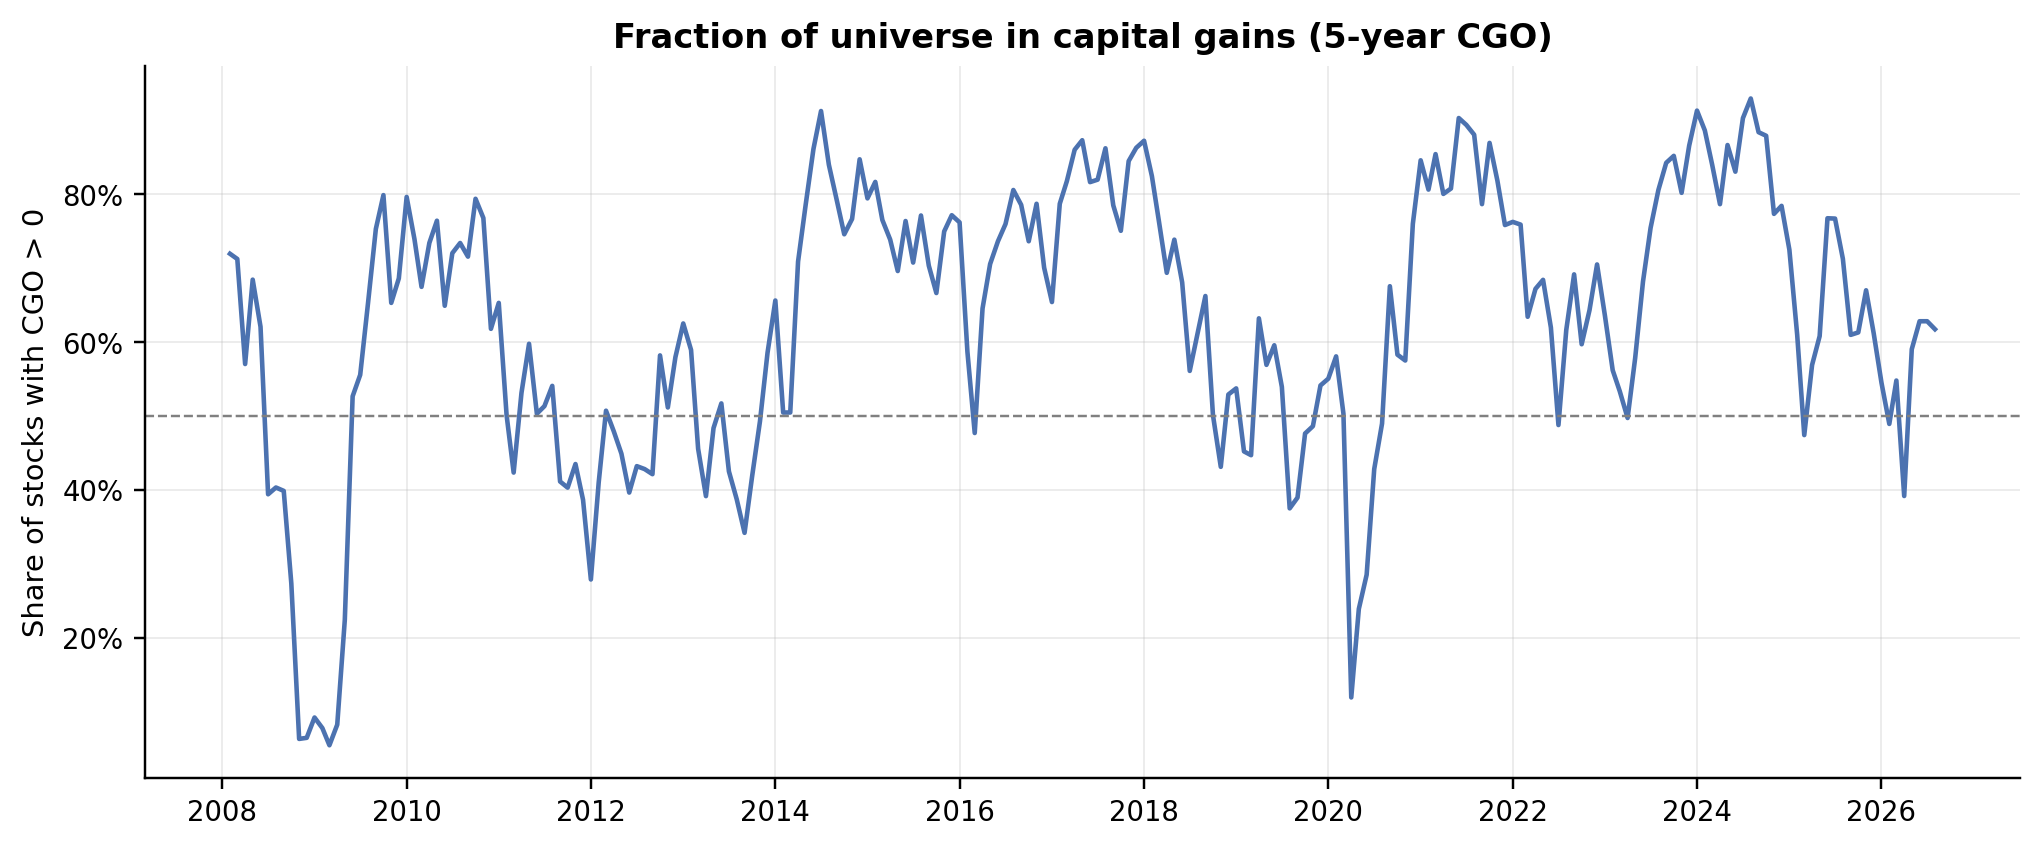

In [3]:
g = panel.groupby(level="yyyymm")["cgo"]
frac_gain = g.apply(lambda s: (s > 0).sum() / s.notna().sum())
n_gain = g.apply(lambda s: int((s > 0).sum()))
n_loss = g.apply(lambda s: int((s < 0).sum()))

fig, ax = plt.subplots(figsize=(11, 4.2))
x = fl.plotting.to_datetime_index(frac_gain.index)
ax.plot(x, frac_gain, color="#4C72B0", linewidth=1.5)
ax.axhline(0.5, color="grey", linewidth=0.8, linestyle="--")
ax.set_ylabel("Share of stocks with CGO > 0")
ax.set_title("Fraction of universe in capital gains (5-year CGO)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
fl.plotting.savefig(fig, f"{FIGDIR}/80_gain_fraction")

print("含み益銘柄比率: 平均", round(frac_gain.mean(), 3),
      " 最小", round(frac_gain.min(), 3), f"({frac_gain.idxmin()})",
      " 最大", round(frac_gain.max(), 3), f"({frac_gain.idxmax()})")
print("gain側銘柄数 最小:", int(n_gain.min()), f"({n_gain.idxmin()})",
      " loss側銘柄数 最小:", int(n_loss.min()), f"({n_loss.idxmin()})")

## 2. スコアの基本特性

- censored 版の `frac_mode` = 反対符号側の比率（タイの塊）
- conditional 版はタイなしだがカバレッジが片側分に減る

In [4]:
chars = fl.altdata.score_characteristics(panel, SCORES)
chars[["n_stocks_mean", "coverage_univ", "n_unique_mean", "frac_mode", "rank_autocorr"]]

,n_stocks_mean,coverage_univ,n_unique_mean,frac_mode,rank_autocorr
cgo,317.484,0.854,317.484,0.003,0.941
gain_cens,317.484,0.854,205.650,0.370,0.908
loss_cens,317.484,0.854,113.834,0.630,0.844
gain_only,204.650,0.540,204.650,0.007,0.865
loss_only,112.834,0.314,112.834,0.012,0.753


## 2.5 カバレッジの時系列

- `cgo`: turnover 履歴 260 週が必要 → 新規上場・データ薄の銘柄が欠ける
- `gain_only` / `loss_only`: さらに**符号の条件**が乗るためカバレッジが市場局面で大きく振れる

,mean,min,max,min_month,bench_mean
cov_cgo,0.854,0.727,0.948,200806,0.919
cov_gain_only,0.540,0.042,0.828,200902,0.665
cov_loss_only,0.314,0.058,0.755,202407,0.254


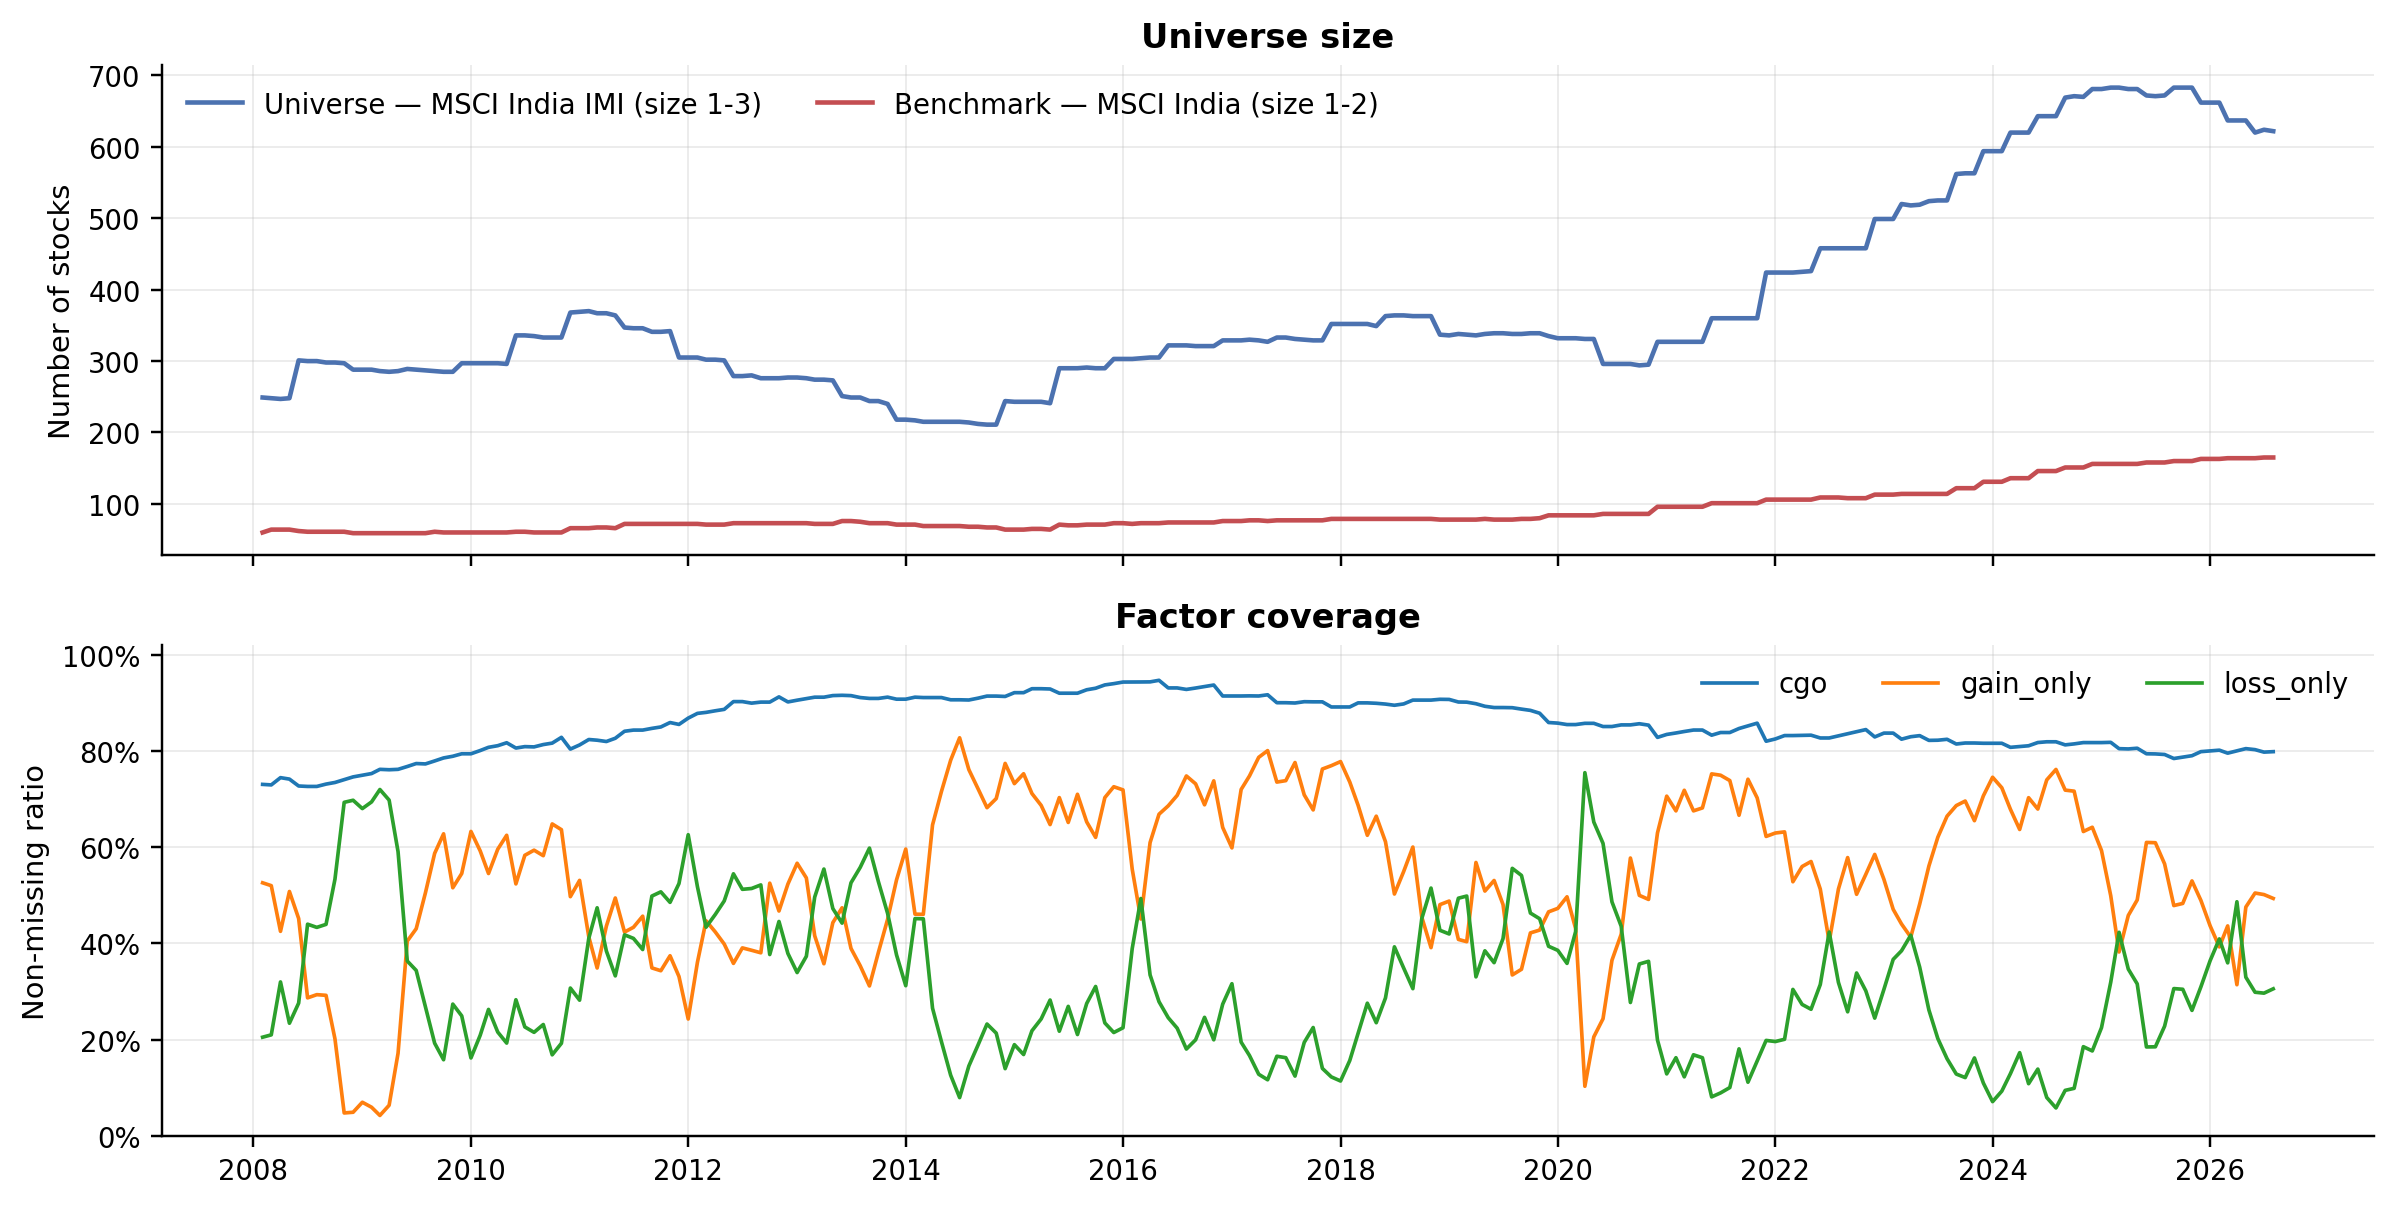

In [5]:
cov = fl.data.coverage(panel, ["cgo", "gain_only", "loss_only"])
fig = fl.plotting.plot_coverage(cov, factor_cols=["cov_cgo", "cov_gain_only", "cov_loss_only"])
fl.plotting.savefig(fig, f"{FIGDIR}/86_coverage")

summary_cov = cov[["cov_cgo", "cov_gain_only", "cov_loss_only"]].agg(["mean", "min", "max"]).T
summary_cov["min_month"] = [cov[c].idxmin() for c in summary_cov.index]
# ベンチマーク銘柄に対するカバレッジも併記
b = panel[panel["in_bench"]]
for c in ["cgo", "gain_only", "loss_only"]:
    summary_cov.loc[f"cov_{c}", "bench_mean"] = float(
        b.groupby(level="yyyymm")[c].count().div(b.groupby(level="yyyymm").size()).mean())
summary_cov

## 3. 分位分析

- conditional 版は `min_universe=50`（片側の銘柄数が 50 未満の月を除外）。
  除外月数も確認する（**暴落期に gain 側が消える = サンプル選択**である点に注意）
- conditional 版の NA バケット = 反対符号の銘柄 + CGO 未計算銘柄

In [6]:
res, summ = {}, {}
for c in SCORES:
    mu = MIN_UNIVERSE if c in ("gain_only", "loss_only") else 0
    res[c] = fl.quantile.quantile_returns(panel, f"{c}_blom", q=Q, ascending=True, min_universe=mu)
    summ[c] = fl.quantile.quantile_summary(res[c], weighting=WEIGHTING)

for c in ("gain_only", "loss_only"):
    n_all = panel.groupby(level="yyyymm").size().shape[0] - 1  # 最終月はリターンなし
    n_used = res[c]["ew"].shape[0]
    print(f"{c}: 使用 {n_used} / {n_all} ヶ月（min_universe={MIN_UNIVERSE} で除外 {n_all-n_used}）")

spread = f"Q{Q}-Q1"
pd.concat({c: summ[c].loc[[f"Q{Q}", spread, "NA"],
    ["ann_excess", "ann_excess_arith", "te", "IR", "t_stat_NW", "n_stocks_mean"]]
    for c in SCORES}, names=["score", "bucket"])

gain_only: 使用 214 / 222 ヶ月（min_universe=50 で除外 8）
loss_only: 使用 196 / 222 ヶ月（min_universe=50 で除外 26）


ann_excess  ann_excess_arith    te     IR  t_stat_NW  n_stocks_mean
score     bucket                                                                     
cgo       Q5           0.080             0.068 0.108  0.627      3.035         63.297
          Q5-Q1        0.081             0.104 0.221  0.470      2.111            NaN
          NA          -0.081            -0.060 0.124 -0.482     -2.153         57.626
gain_cens Q5           0.080             0.069 0.106  0.654      3.166         63.297
          Q5-Q1        0.077             0.088 0.165  0.531      2.283            NaN
          NA          -0.081            -0.060 0.124 -0.482     -2.153         57.626
loss_cens Q5           0.027             0.024 0.099  0.242      1.287         63.288
          Q5-Q1        0.031             0.050 0.189  0.263      1.181            NaN
          NA          -0.081            -0.060 0.124 -0.482     -2.153         57.626
gain_only Q5           0.078             0.070 0.118  0.598      2.923         42.196
          Q5-Q1        0.063             0.069 0.131  0.531      2.449            NaN
          NA          -0.082            -0.063 0.111 -0.568     -2.409        166.294
loss_only Q5          -0.052            -0.034 0.116 -0.295     -1.194         24.454
          Q5-Q1       -0.014             0.007 0.199  0.033      0.138            NaN
          NA           0.002             0.006 0.082  0.076      0.357        260.051

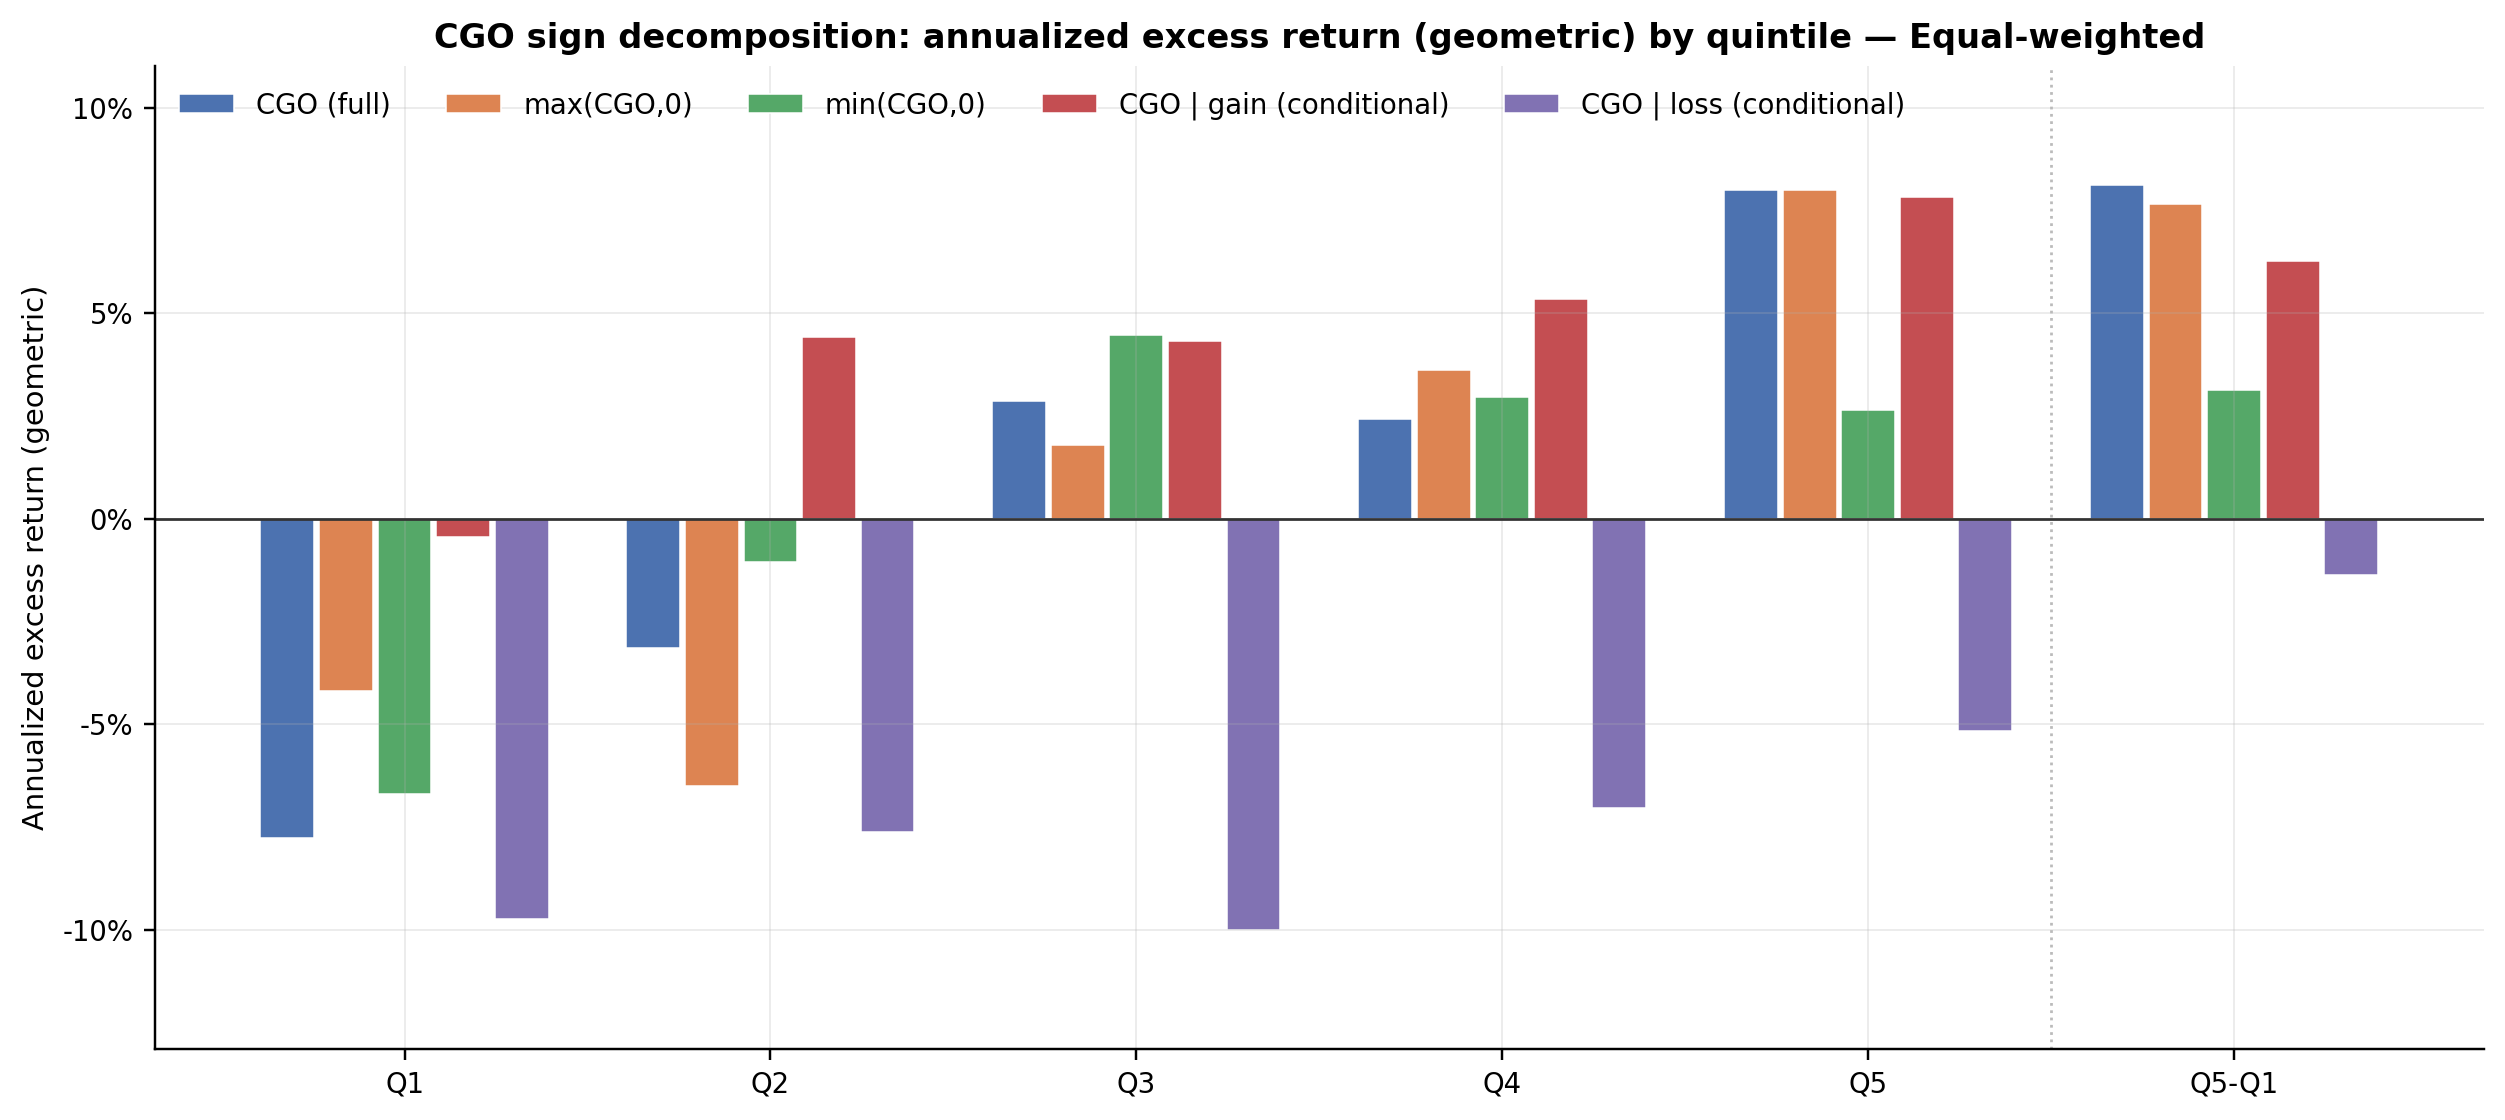

In [7]:
LAB = {"cgo": "CGO (full)", "gain_cens": "max(CGO,0)", "loss_cens": "min(CGO,0)",
       "gain_only": "CGO | gain (conditional)", "loss_only": "CGO | loss (conditional)"}
fig = fl.plotting.plot_variant_quantile_bar(summ, q=Q, factor="CGO sign decomposition",
                                            weighting=WEIGHTING, labels=LAB)
fl.plotting.savefig(fig, f"{FIGDIR}/81_quantile_bar_signs");

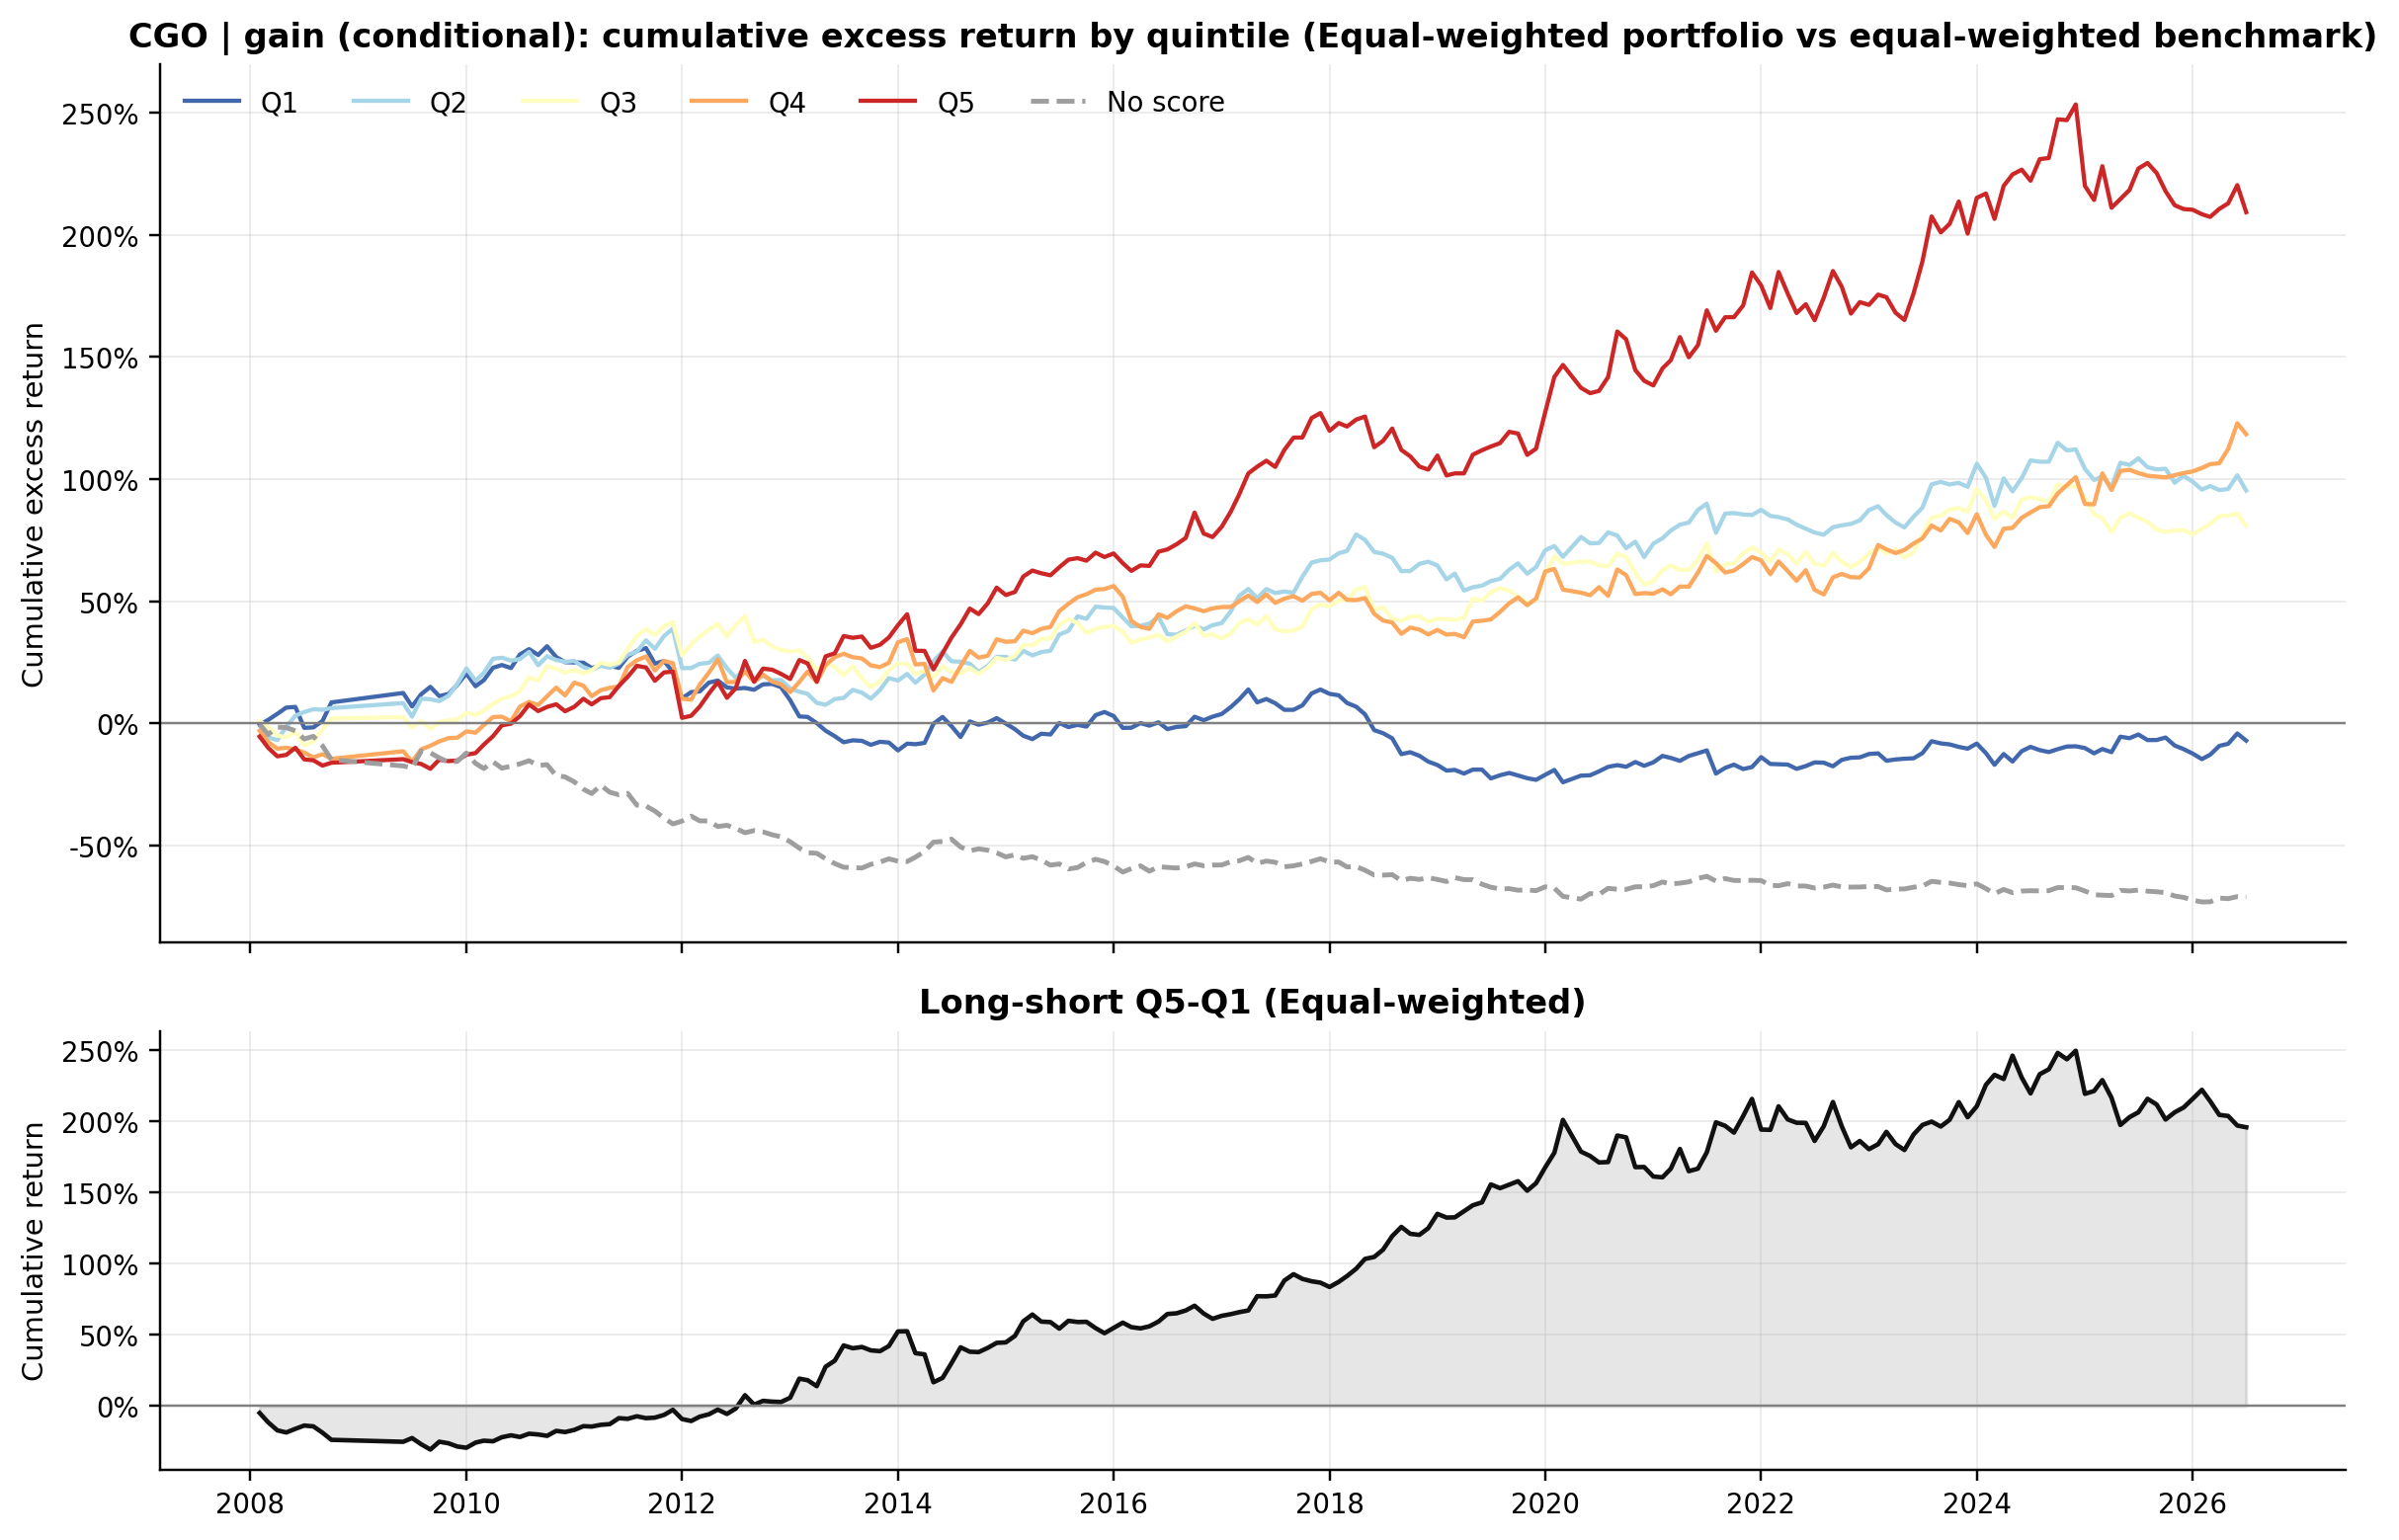

In [8]:
fig = fl.plotting.plot_quantile_timeseries(res["gain_only"], weighting=WEIGHTING, q=Q,
                                           factor="CGO | gain (conditional)", show_na=True)
fl.plotting.savefig(fig, f"{FIGDIR}/82_gain_only_ts");

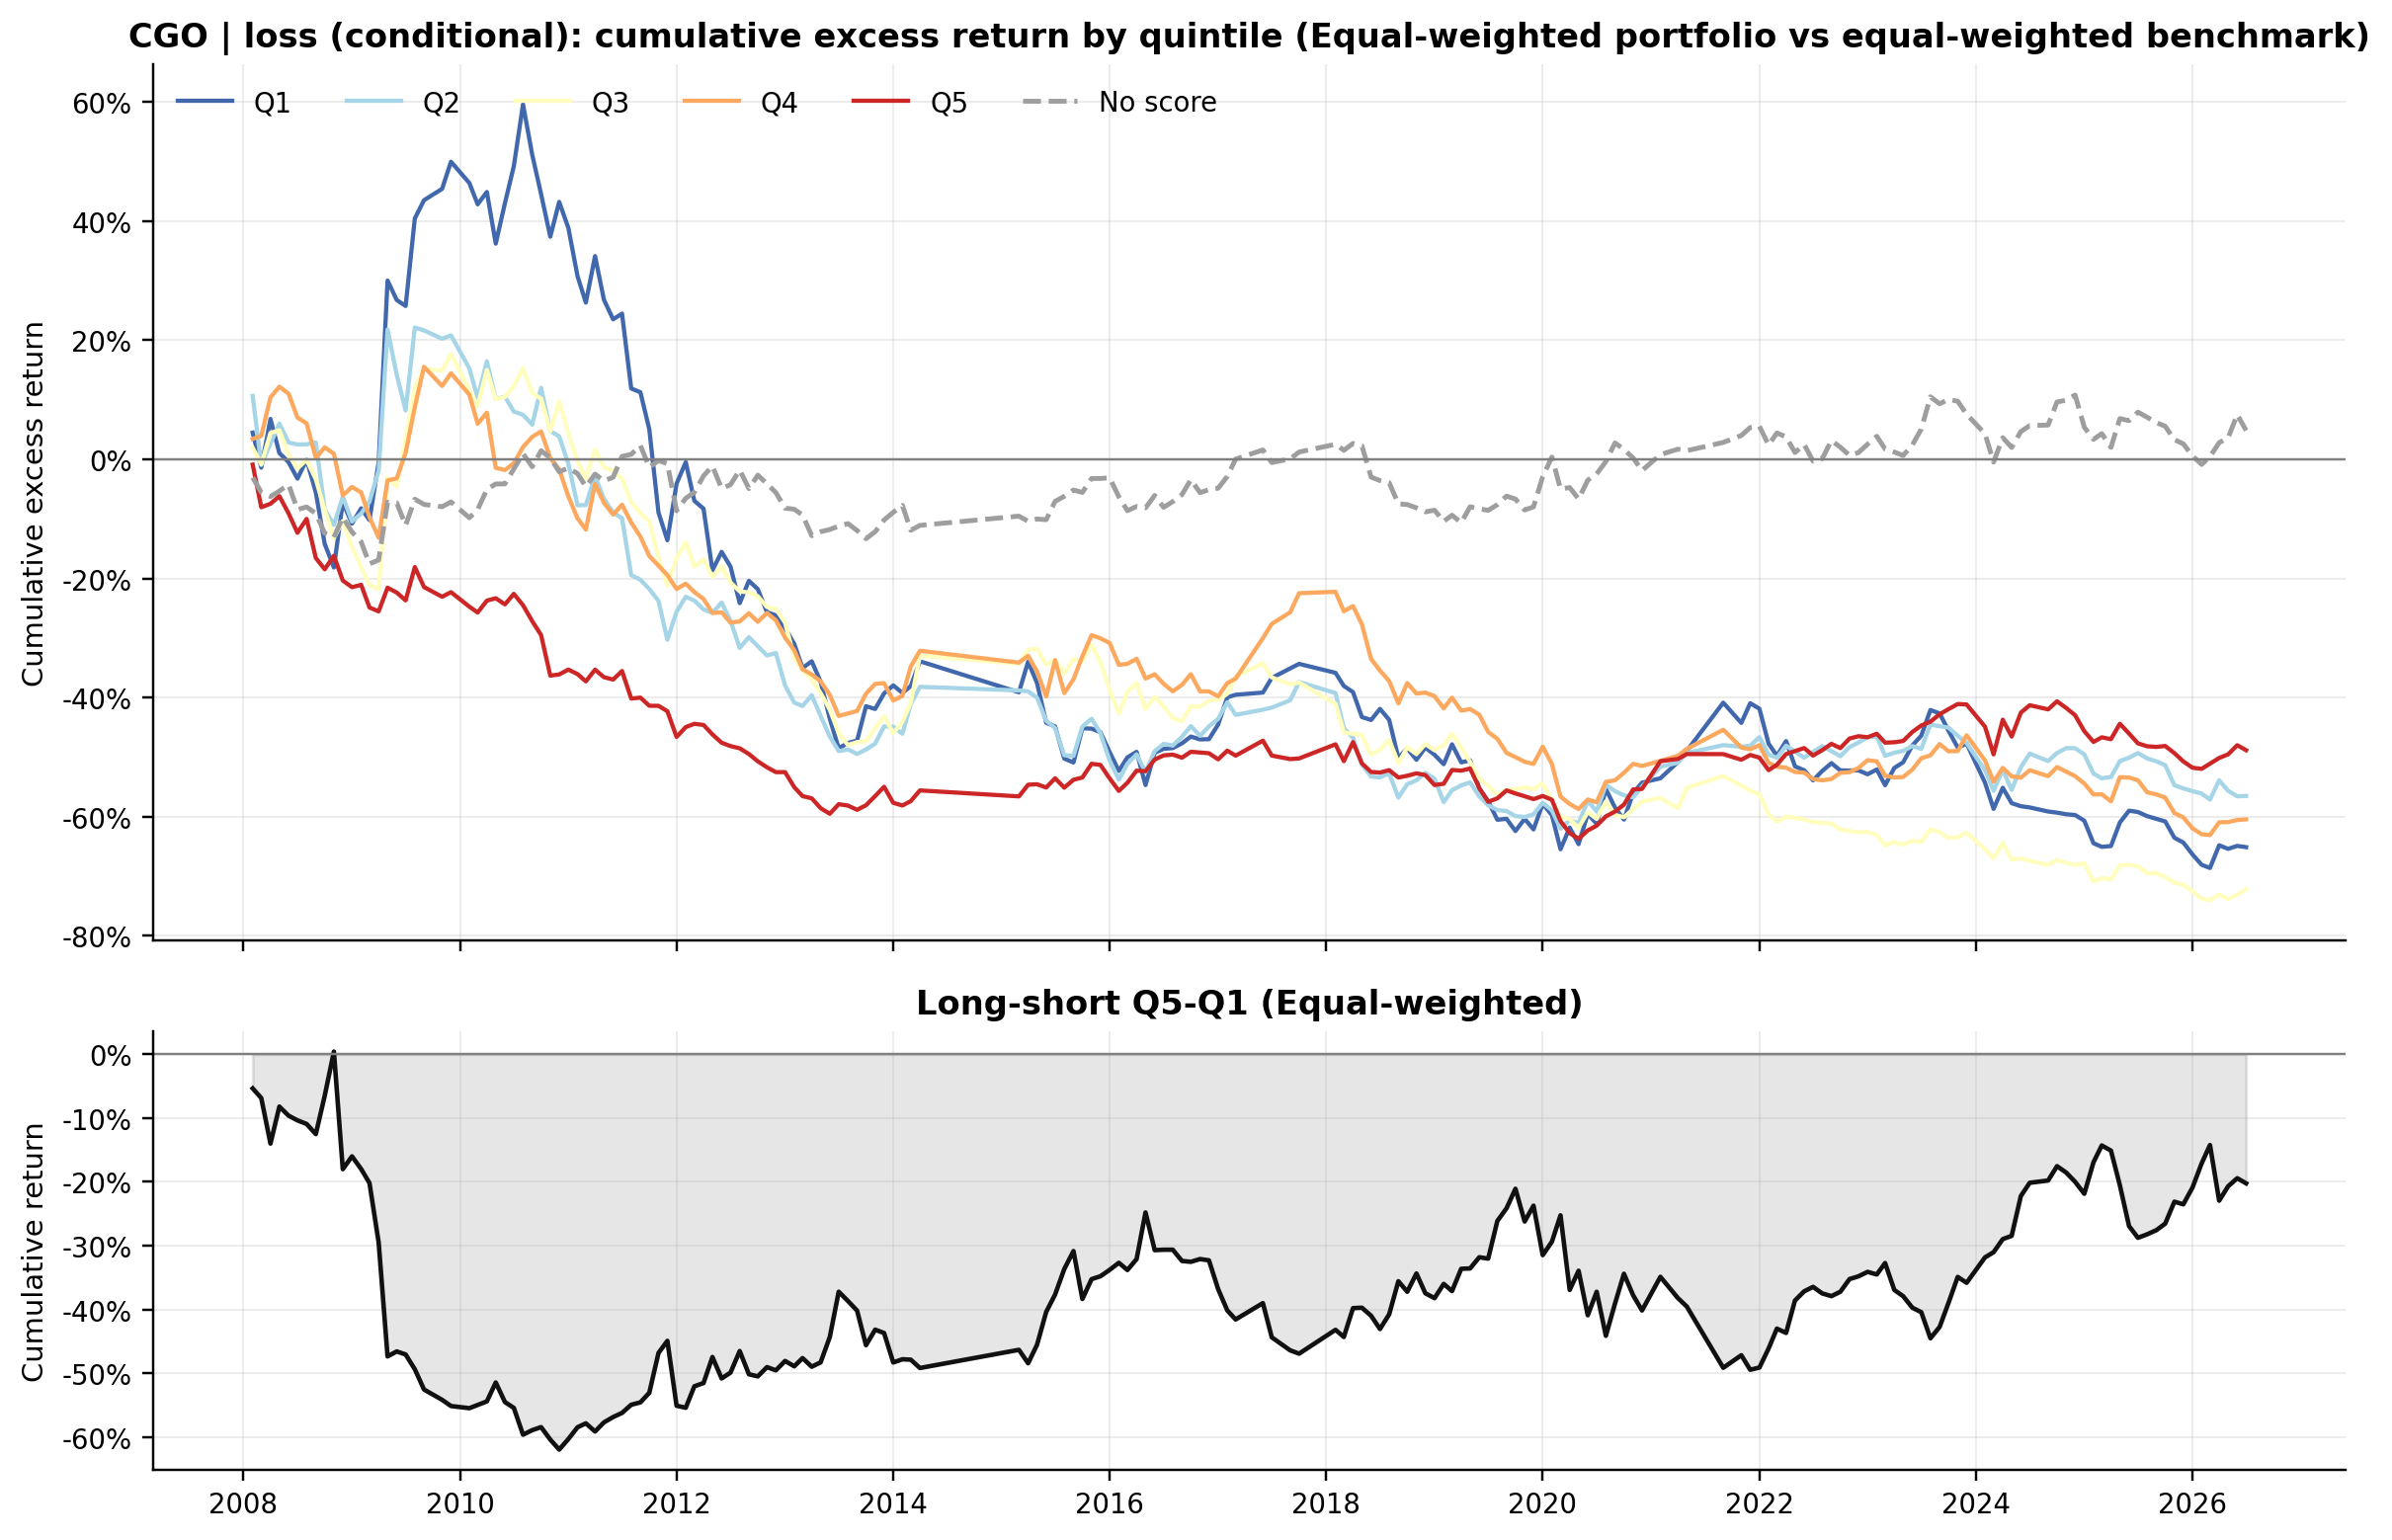

In [9]:
fig = fl.plotting.plot_quantile_timeseries(res["loss_only"], weighting=WEIGHTING, q=Q,
                                           factor="CGO | loss (conditional)", show_na=True)
fl.plotting.savefig(fig, f"{FIGDIR}/83_loss_only_ts");

## 4. IC（raw / momentum 中立）

In [10]:
for c in SCORES:
    panel = fl.preprocess.standardize_panel(
        panel, c, method="blom", group_col="sector",
        control_cols=["log_cap", "mom12_1_blom"], suffix="_blom_mn")

ics = {c: fl.ic.information_coefficient(panel, f"{c}_blom", "fwd_rtn") for c in SCORES}
ics_mn = {c: fl.ic.information_coefficient(panel, f"{c}_blom_mn", "fwd_rtn") for c in SCORES}

pd.concat({
    "raw": pd.DataFrame({LAB[c]: fl.ic.ic_summary(ics[c]) for c in SCORES}).T,
    "mom_neutral": pd.DataFrame({LAB[c]: fl.ic.ic_summary(ics_mn[c]) for c in SCORES}).T,
}, names=["variant", "score"])[["n_months", "mean_IC", "ICIR_ann", "t_stat_NW", "hit_ratio"]]

n_months  mean_IC  ICIR_ann  t_stat_NW  hit_ratio
variant     score                                                                      
raw         CGO (full)                 222.000    0.054     0.917      4.211      0.631
            max(CGO,0)                 222.000    0.054     0.986      4.401      0.635
            min(CGO,0)                 222.000    0.050     0.903      4.106      0.608
            CGO | gain (conditional)   217.000    0.026     0.659      3.049      0.571
            CGO | loss (conditional)   221.000    0.016     0.331      1.595      0.566
mom_neutral CGO (full)                 222.000    0.022     0.598      2.819      0.563
            max(CGO,0)                 222.000    0.023     0.654      2.981      0.536
            min(CGO,0)                 222.000    0.017     0.507      2.401      0.577
            CGO | gain (conditional)   217.000    0.014     0.410      1.810      0.521
            CGO | loss (conditional)   221.000   -0.005    -0.133     -0.614      0.516

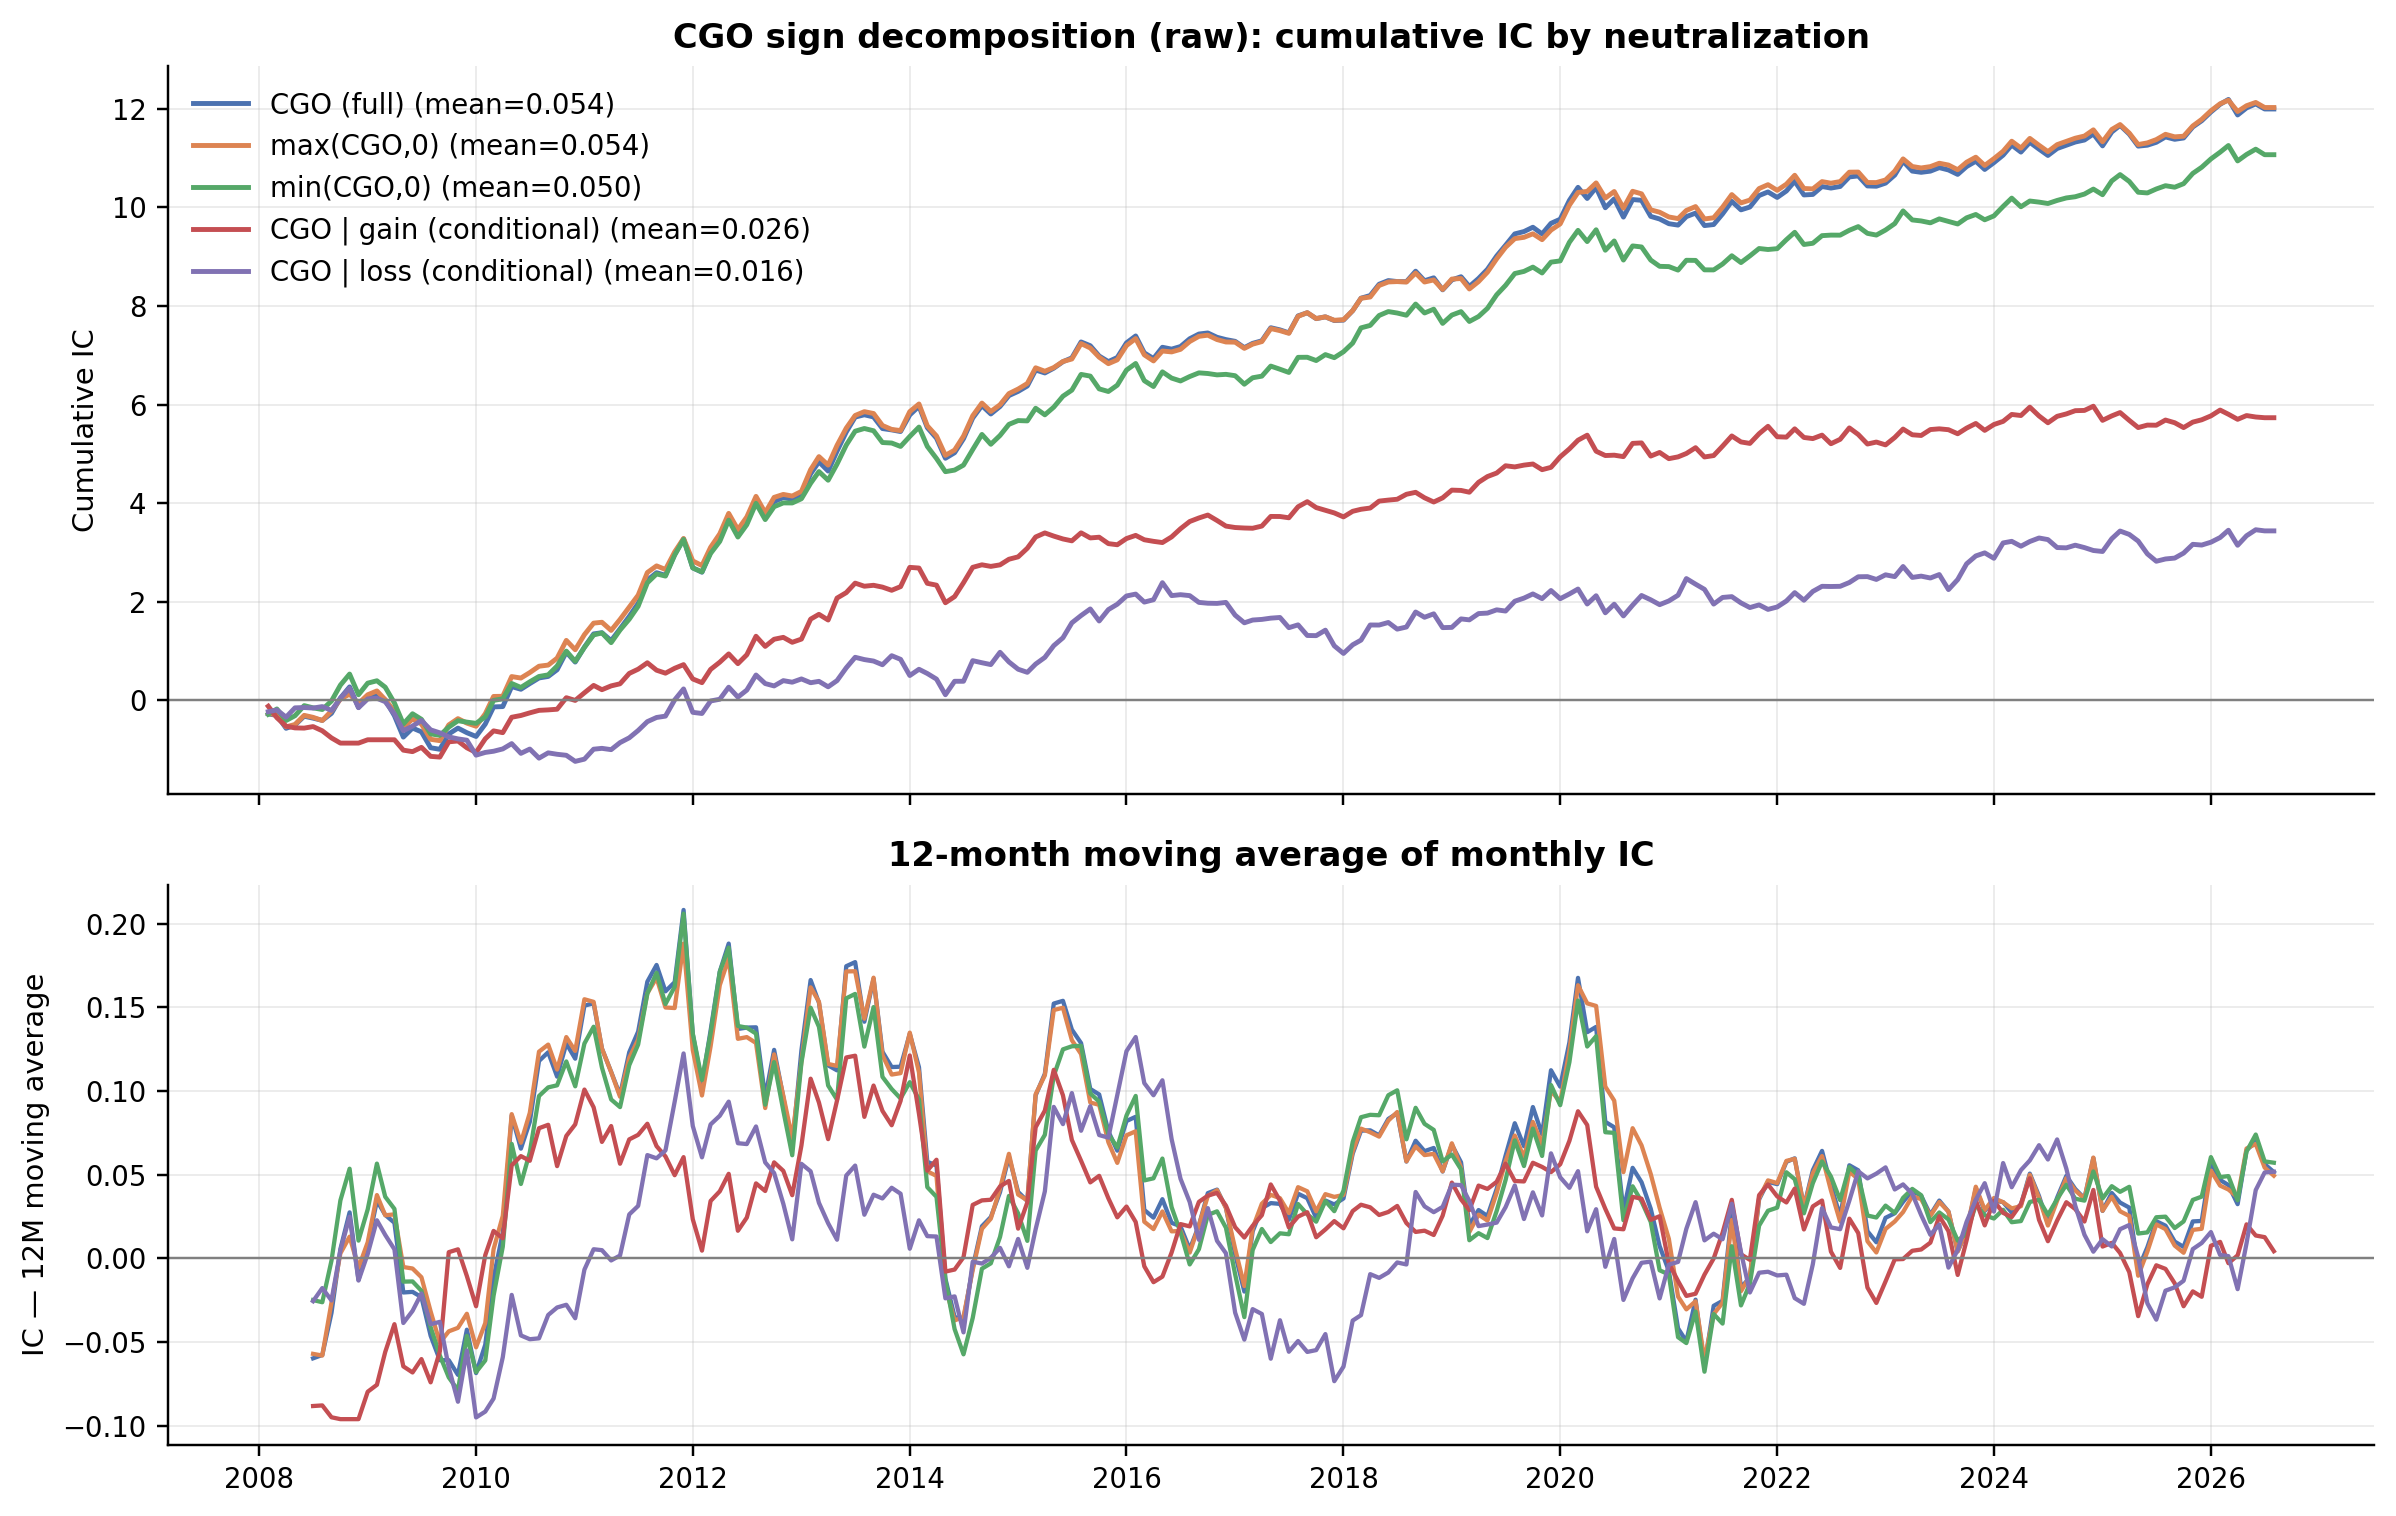

In [11]:
fig = fl.plotting.plot_cumulative_ic_compare(ics, factor="CGO sign decomposition (raw)", labels=LAB)
fl.plotting.savefig(fig, f"{FIGDIR}/84_cumulative_ic_raw");

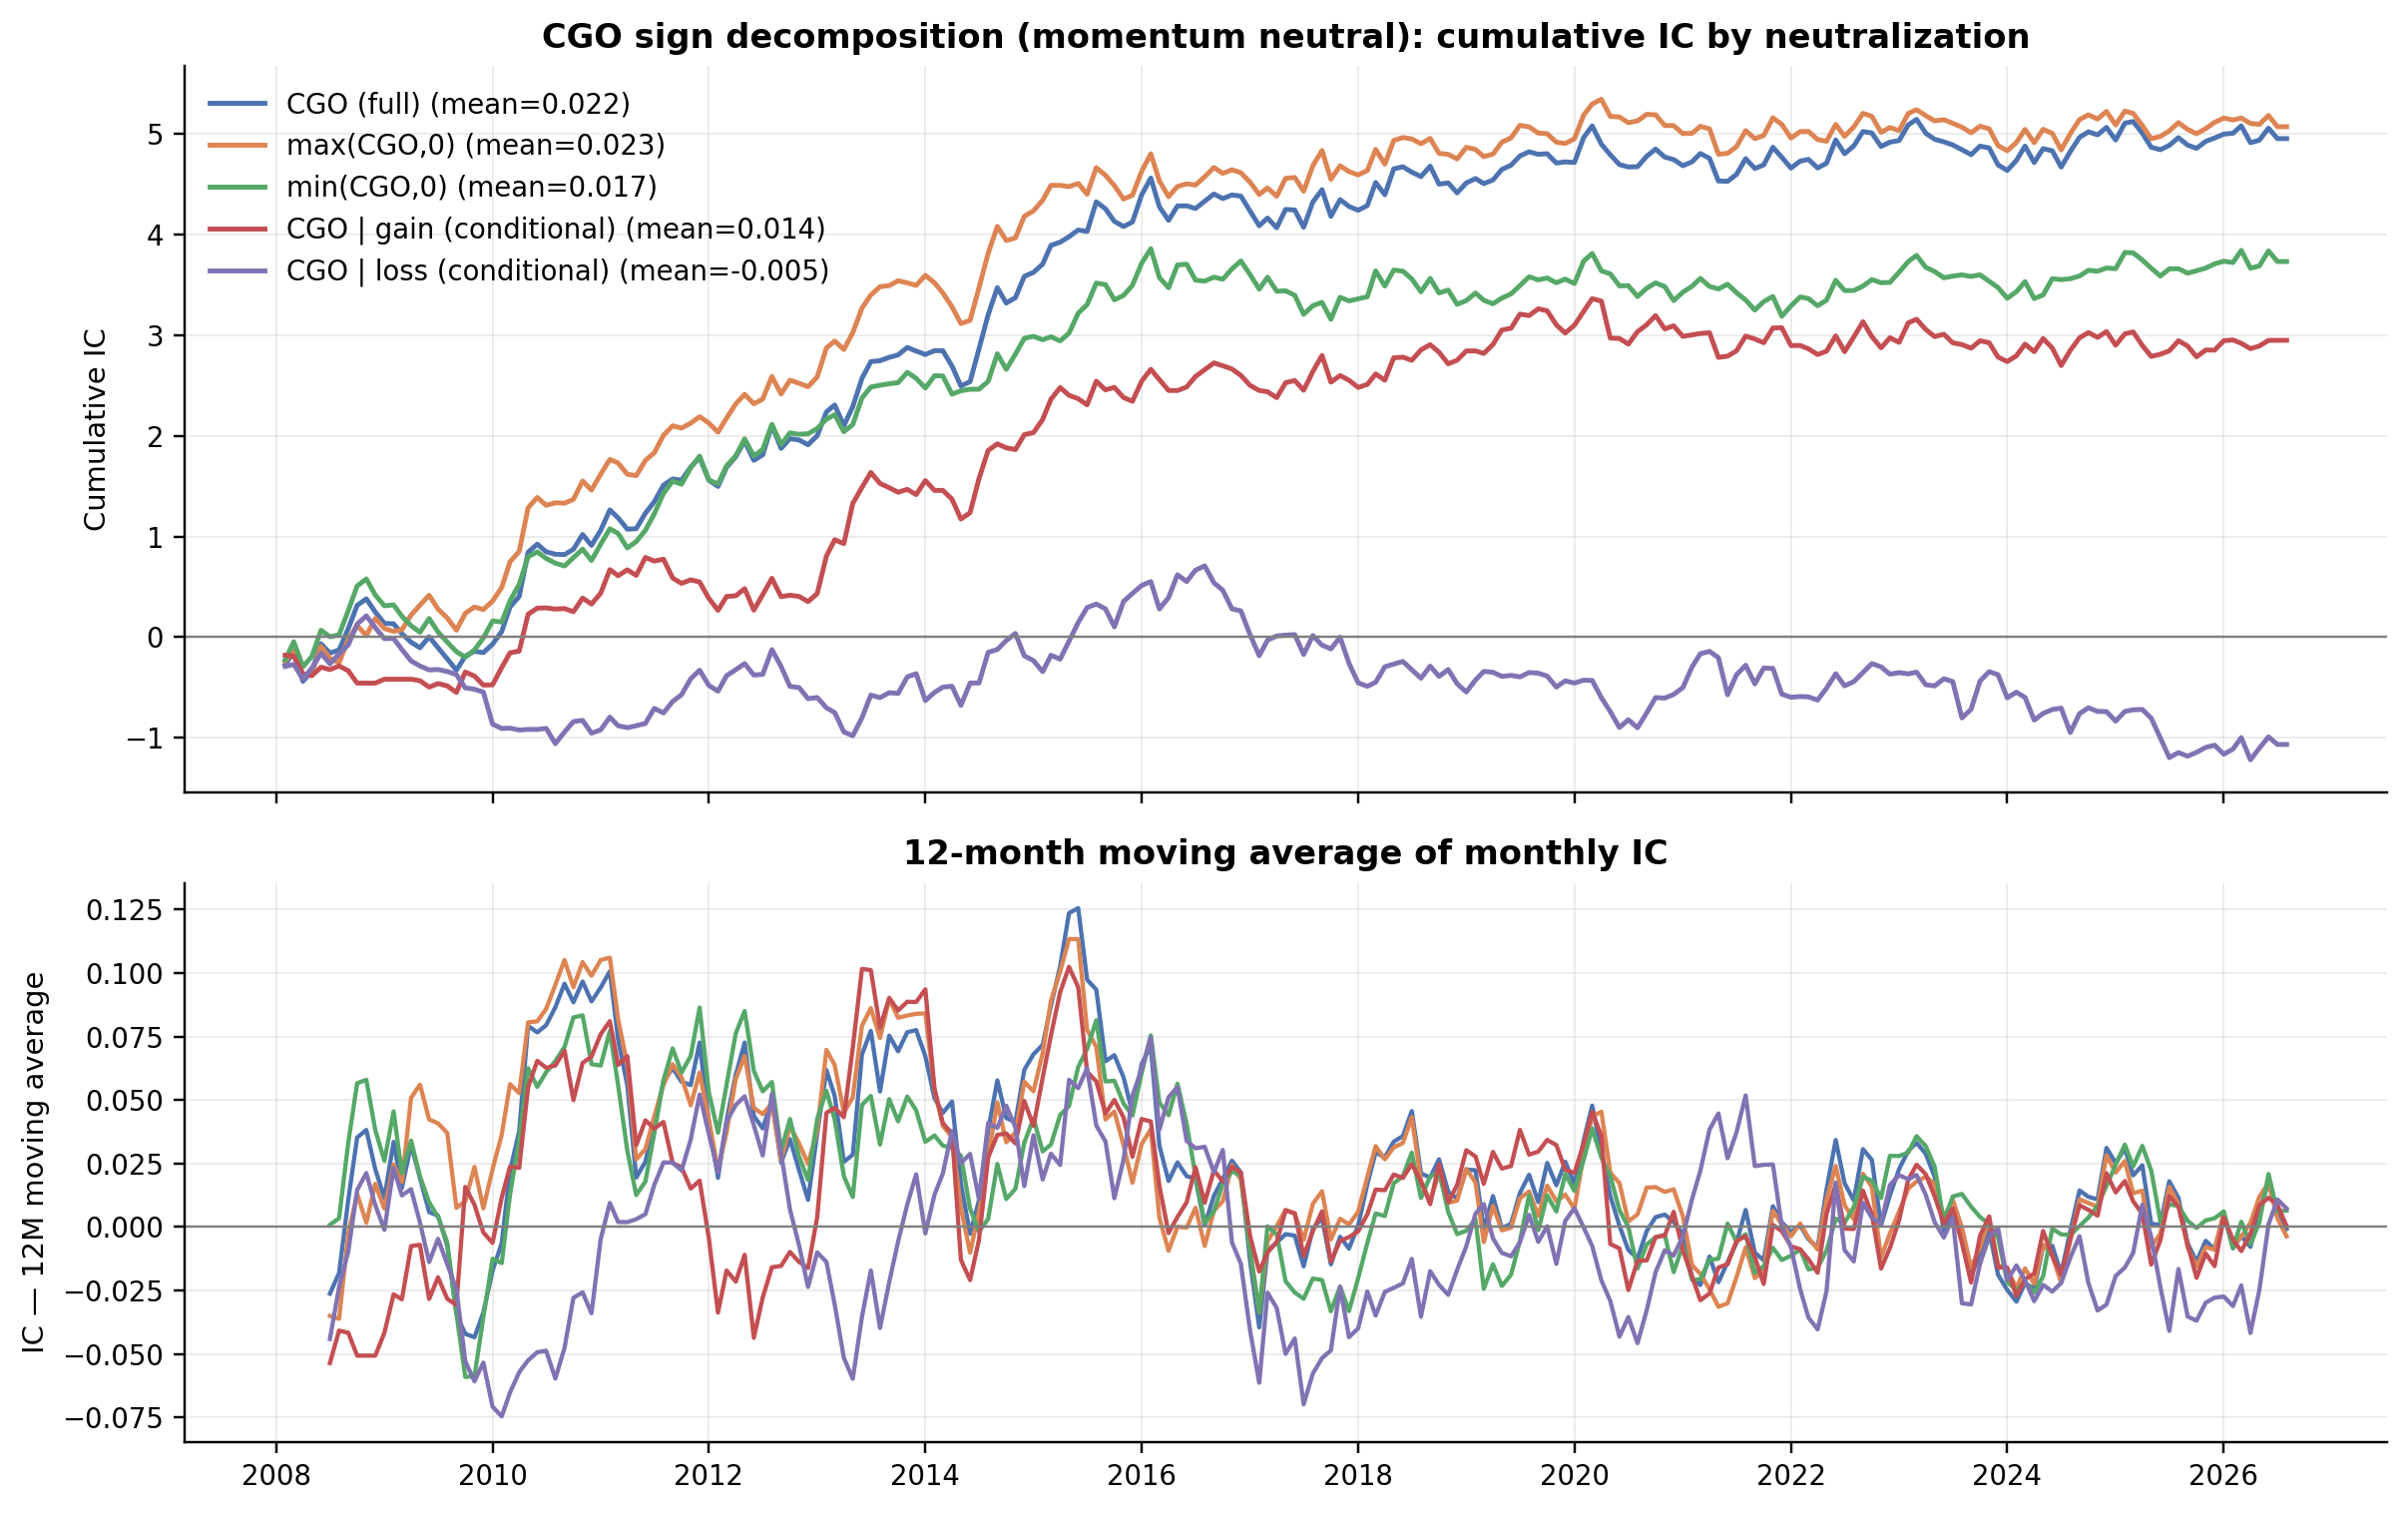

In [12]:
fig = fl.plotting.plot_cumulative_ic_compare(ics_mn, factor="CGO sign decomposition (momentum neutral)",
                                             labels=LAB)
fl.plotting.savefig(fig, f"{FIGDIR}/85_cumulative_ic_mn");

## 5. 符号そのもの（gain vs loss の2グループ）

分位より粗いが、タイ問題もサンプル選択もない最も素直な検証。

In [13]:
sub = panel.dropna(subset=["cgo", "fwd_rtn"])
sign = np.where(sub["cgo"] > 0, "gain", "loss")
grp = sub.groupby([sub.index.get_level_values("yyyymm"), sign])["fwd_rtn"].mean().unstack()
grp["gain-loss"] = grp["gain"] - grp["loss"]
s = fl.metrics.summarize(grp["gain-loss"])
print("gain群(EW) − loss群(EW) の月次リターン差:")
s[["ann_return", "ann_vol", "IR", "t_stat_NW", "hit_ratio", "skew", "worst_month"]].to_frame("gain-loss").T

gain群(EW) − loss群(EW) の月次リターン差:


,ann_return,ann_vol,IR,t_stat_NW,hit_ratio,skew,worst_month
gain-loss,0.074,0.152,0.487,2.282,0.595,-1.033,-0.211


---

## 読みどころ

1. **censored vs conditional**: `frac_mode`（タイの塊）の大きさと、それが分位に与える歪み
2. **非対称性**: 益側の濃淡（gain_only）と損側の濃淡（loss_only）のどちらに情報があるか。
   処分効果の教科書的予測は「益側で強い正の予測力」
3. conditional 版の**サンプル選択**: gain 側は強気相場でしか定義されない点を
   使用月数と NA バケットで確認
4. 符号ダミー（§5）だけでどこまで説明できるか vs 符号内の濃淡の寄与